<a href="https://colab.research.google.com/github/pmhiremath/customer_lifetime_value/blob/main/customer_lifetime_value.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Customer Lifetime Value (CLV) Predictor

**Dataset:** UCI Online Retail II (Kaggle / UCI ML Repository)  
Run each cell top to bottom in order.

## Cell 1 — Imports & Global Settings

In [ ]:
# importing requried library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline



In [ ]:
# setting the theme of visulation
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2a4a",
    "figure.dpi":       150,
})


## Cell 2 — STEP 1: Load & Validate Dataset



** GET THE DATASET:**
- (Kaggle): https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

- Place `online_retail_II.csv` in the same folder as this notebook.

In [ ]:
print("  STEP 1 - LOAD & VALIDATE DATASET")

FILE_PATH = "online_retail_II.csv"

df = pd.read_csv(FILE_PATH,  parse_dates=["InvoiceDate"])

print(f"\n[1.1]  Raw dataset shape          : {df.shape}")
print(f"[1.2]  Date range                 : "
      f"{df['InvoiceDate'].min().date()} - {df['InvoiceDate'].max().date()}")
print(f"[1.3]  Unique customers (raw)     : {df['Customer ID'].nunique():,}")
print(f"[1.4]  Unique invoices  (raw)     : {df['Invoice'].nunique():,}")

# Show missing values snapshot
print(f"\n[1.5]  Missing values:")
print(df.isnull().sum().to_string())

# Count cancellations before removing them
n_cancels = df["Invoice"].astype(str).str.startswith("C").sum()
print(f"\n[1.6]  Cancellation rows          : {n_cancels:,}")

  STEP 1 - LOAD & VALIDATE DATASET

[1.1]  Raw dataset shape          : (1067371, 8)
[1.2]  Date range                 : 2009-12-01 - 2011-12-09
[1.3]  Unique customers (raw)     : 5,942
[1.4]  Unique invoices  (raw)     : 53,628

[1.5]  Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0

[1.6]  Cancellation rows          : 19,494


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


## Cell 3 — STEP 2: Data Cleaning



- Remove cancellations → revenue must reflect goods shipped, not reversed
- Remove no Customer ID → CLV requires a persistent customer identity
- Remove Quantity ≤ 0 → a zero or negative quantity has no revenue
- Remove Price ≤ 0 → a zero price means a gift or data error; both distort average order value calculations

Revenue = Quantity × Price — computed after all filters to ensure every row represents a genuine, completed, identifiable sale.

In [ ]:
print("  STEP 2  DATA CLEANING")

df_clean = df.copy()

# 2.1 Remove cancellation invoices (Invoice starts with 'C')
mask_cancel = df_clean["Invoice"].astype(str).str.startswith("C")
df_clean = df_clean[~mask_cancel]
print(f"\n[2.1]  Cancellations removed      : {mask_cancel.sum():,} rows")

# 2.2 Remove rows with no Customer ID
n_anon = df_clean["Customer ID"].isnull().sum()
df_clean.dropna(subset=["Customer ID"], inplace=True)
print(f"[2.2]  Anonymous rows removed     : {n_anon:,} rows")

# 2.3 Remove rows with non-positive Quantity or Price
n_bad_qty   = (df_clean["Quantity"] <= 0).sum()
n_bad_price = (df_clean["Price"] <= 0).sum()
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]
print(f"[2.3]  Non-positive Quantity rows : {n_bad_qty:,} rows removed")
print(f"[2.4]  Non-positive Price rows    : {n_bad_price:,} rows removed")

# 2.4 Cast Customer ID to integer string (no decimal)
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int).astype(str)

# 2.5 Compute Revenue per line item — the fundamental unit
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

print(f"\n[2.5]  Clean dataset shape        : {df_clean.shape}")
print(f"[2.6]  Unique customers (clean)   : {df_clean['Customer ID'].nunique():,}")
print(f"[2.7]  Total revenue              : \u00a3{df_clean['Revenue'].sum():,.2f}")
print(f"\n[2.8]  Sample (first 5 rows):")
df_clean[["Invoice", "InvoiceDate", "Customer ID",
                 "Quantity", "Price", "Revenue", "Country"]].head()

  STEP 2  DATA CLEANING

[2.1]  Cancellations removed      : 19,494 rows
[2.2]  Anonymous rows removed     : 242,257 rows
[2.3]  Non-positive Quantity rows : 0 rows removed
[2.4]  Non-positive Price rows    : 71 rows removed

[2.5]  Clean dataset shape        : (805549, 9)
[2.6]  Unique customers (clean)   : 5,878
[2.7]  Total revenue              : £17,743,429.18

[2.8]  Sample (first 5 rows):


,Invoice,InvoiceDate,Customer ID,Quantity,Price,Revenue,Country
0,489434,2009-12-01 07:45:00,13085,12,6.95,83.4,United Kingdom
1,489434,2009-12-01 07:45:00,13085,12,6.75,81.0,United Kingdom
2,489434,2009-12-01 07:45:00,13085,12,6.75,81.0,United Kingdom
3,489434,2009-12-01 07:45:00,13085,48,2.10,100.8,United Kingdom
4,489434,2009-12-01 07:45:00,13085,24,1.25,30.0,United Kingdom


## Cell 4 — EDA Visualisations — Act 1: Revenue Landscape (3-panel)

**WHY:** Before modelling CLV, we need to understand where revenue comes from. The Pareto principle is universal in e-commerce: ~20% of customers generate ~80% of revenue. Identifying this concentration shapes which customer segments are worth retaining vs acquiring.

  EDA \ ACT 1: REVENUE LANDSCAPE


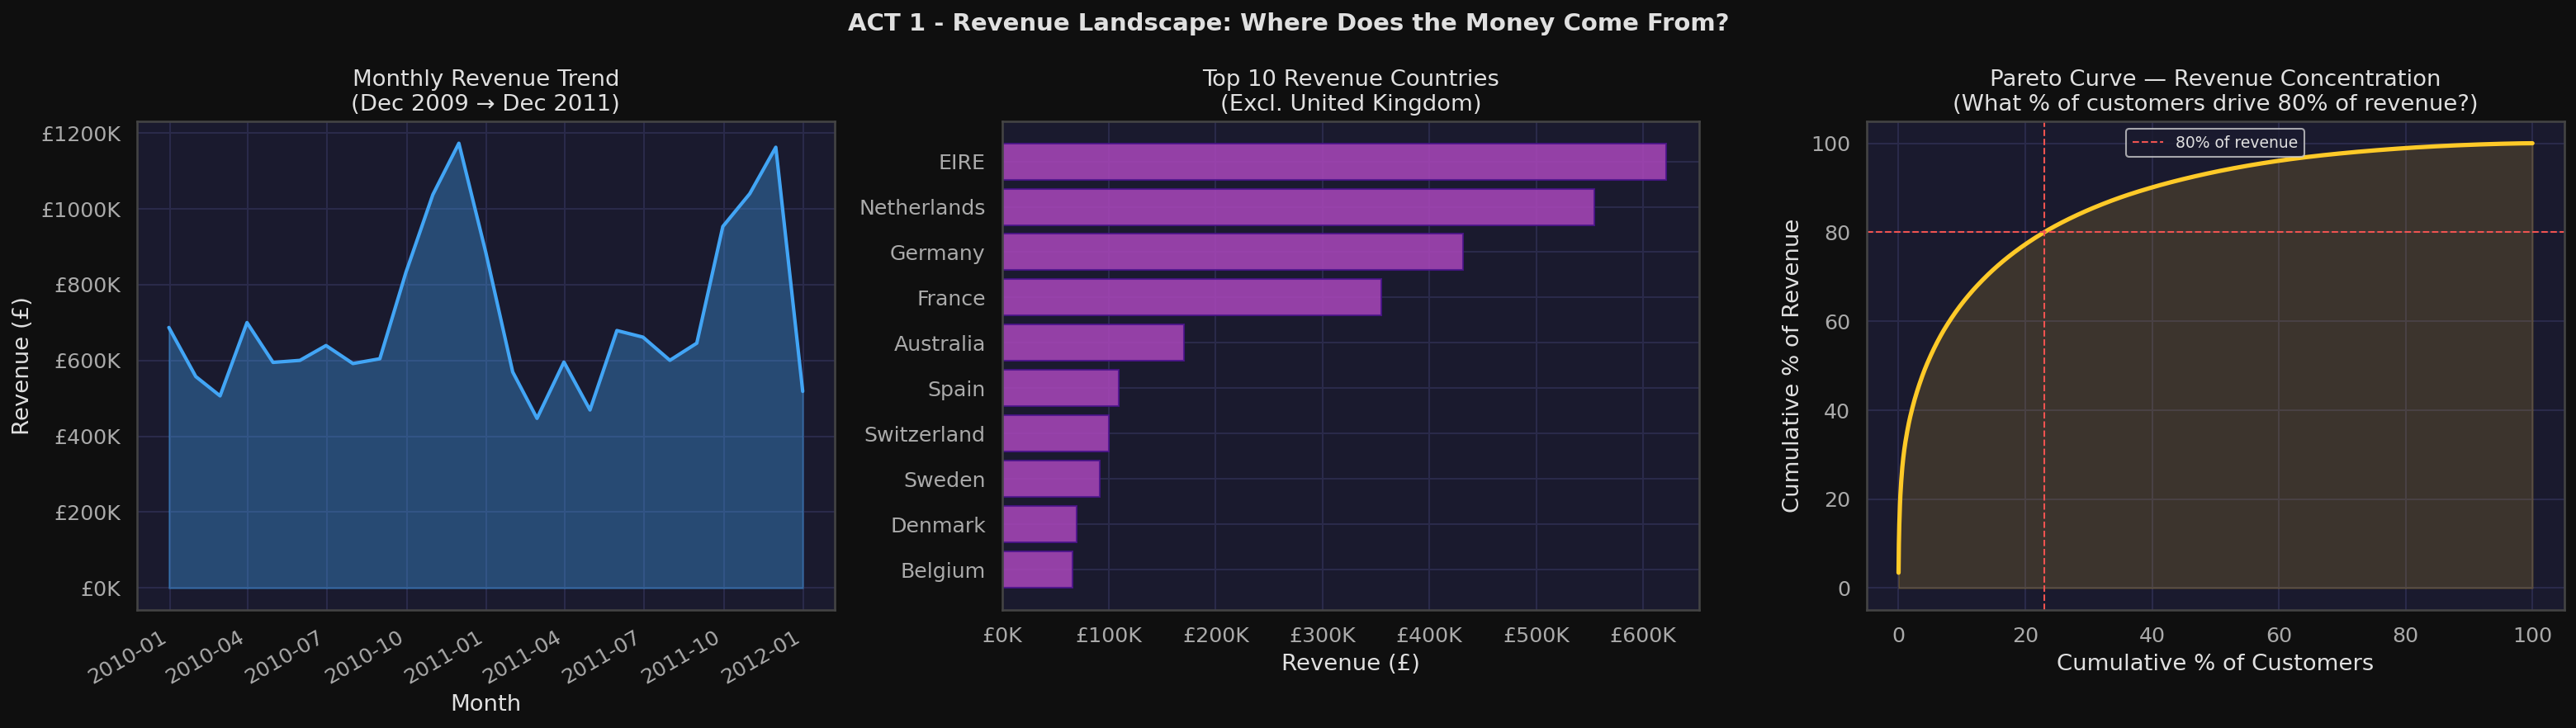

In [ ]:
print("  EDA \ ACT 1: REVENUE LANDSCAPE")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("ACT 1 - Revenue Landscape: Where Does the Money Come From?",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — Monthly revenue trend
ax = axes[0]
monthly_rev = (df_clean
               .set_index("InvoiceDate")["Revenue"]
               .resample("M")
               .sum())
ax.fill_between(monthly_rev.index, monthly_rev.values,
                alpha=0.35, color="#42a5f5")
ax.plot(monthly_rev.index, monthly_rev.values,
        color="#42a5f5", lw=2)
ax.set_title("Monthly Revenue Trend\n(Dec 2009 \u2192 Dec 2011)",
             color="#e0e0e0")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (\u00a3)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"\u00a3{x/1e3:.0f}K"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Panel 2 — Top 10 countries by revenue (excl. UK to show international mix)
ax = axes[1]
country_rev = (df_clean[df_clean["Country"] != "United Kingdom"]
               .groupby("Country")["Revenue"]
               .sum()
               .sort_values(ascending=True)
               .tail(10))
ax.barh(country_rev.index, country_rev.values,
        color="#ab47bc", edgecolor="#4a148c", alpha=0.85)
ax.set_title("Top 10 Revenue Countries\n(Excl. United Kingdom)",
             color="#e0e0e0")
ax.set_xlabel("Revenue (\u00a3)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"\u00a3{x/1e3:.0f}K"))

# Panel 3 — Customer revenue concentration (Pareto curve)
ax = axes[2]
cust_rev = (df_clean.groupby("Customer ID")["Revenue"]
            .sum()
            .sort_values(ascending=False))
cum_pct  = cust_rev.cumsum() / cust_rev.sum() * 100
x_pct    = np.arange(1, len(cum_pct) + 1) / len(cum_pct) * 100
ax.plot(x_pct, cum_pct.values, color="#ffca28", lw=2.5)
ax.axhline(80, color="#ef5350", lw=1, ls="--", label="80% of revenue")
ax.axvline(x_pct[(cum_pct >= 80).argmax()], color="#ef5350", lw=1, ls="--")
ax.fill_between(x_pct, cum_pct.values, alpha=0.15, color="#ffca28")
ax.set_title("Pareto Curve \u2014 Revenue Concentration\n(What % of customers drive 80% of revenue?)",
             color="#e0e0e0")
ax.set_xlabel("Cumulative % of Customers")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### The Pareto Principle in this Dataset
Let's calculate exactly what percentage of customers drive 80% of the revenue to see if the 80/20 rule holds true here.

## Cell 5 — STEP 3: RFM Feature Engineering

**WHY:** RFM is the foundational framework of customer analytics — used by every major e-commerce, banking, and subscription business.

- **Recency (R)** — how recently did the customer last buy? Lower recency = better (more recent)
- **Frequency (F)** — how many distinct transactions has the customer made? Repeat buyers have demonstrated loyalty
- **Monetary (M)** — how much total revenue has this customer generated? The direct input into CLV

**SNAPSHOT DATE:** We use the day after the last transaction in the dataset as the "today" reference point.

In [ ]:
print("  STEP 3 - RFM FEATURE ENGINEERING")

SNAPSHOT_DATE = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"\n[3.1]  Snapshot date (reference 'today') : {SNAPSHOT_DATE.date()}")

rfm = (df_clean
       .groupby("Customer ID")
       .agg(
           Recency   = ("InvoiceDate",  lambda x: (SNAPSHOT_DATE - x.max()).days),
           Frequency = ("Invoice",      "nunique"),
           Monetary  = ("Revenue",      "sum")
       )
       .reset_index())

print(f"\n[3.2]  RFM table shape : {rfm.shape}")
print(f"\n[3.3]  RFM Summary Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2).to_string())

# Flag the top customers by total spend for reference
rfm["Top_Customer"] = rfm["Monetary"] >= rfm["Monetary"].quantile(0.90)
print(f"\n[3.4]  Top 10% customers (by spend) count : "
      f"{rfm['Top_Customer'].sum():,}")


  STEP 3 - RFM FEATURE ENGINEERING

[3.1]  Snapshot date (reference 'today') : 2011-12-10

[3.2]  RFM table shape : (5878, 4)

[3.3]  RFM Summary Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65

[3.4]  Top 10% customers (by spend) count : 588


In [ ]:
rfm


,Customer ID,Recency,Frequency,Monetary,Top_Customer
0,12346,326,12,77556.46,True
1,12347,2,8,5633.32,True
2,12348,75,5,2019.40,False
3,12349,19,4,4428.69,False
4,12350,310,1,334.40,False
...,...,...,...,...,...
5873,18283,4,22,2736.65,False
5874,18284,432,1,461.68,False
5875,18285,661,1,427.00,False
5876,18286,477,2,1296.43,False


## Cell 6 — STEP 4: CLV Computation & RFM Scoring

**WHY:** Historical CLV = total revenue a customer has generated to date. This is the ground truth label our model will learn to predict.

RFM Score (1-5) is computed using quintile binning:
- **Recency:** lower days = better → reversed bin order (5=best)
- **Frequency:** higher = better → normal bin order (5=best)
- **Monetary:** higher = better → normal bin order (5=best)

Combined RFM Score = R_Score + F_Score + M_Score → range [3, 15]

Customer Segments:
- **Champions (12-15)** → VIP rewards
- **Loyal (9-11)** → upsell campaigns
- **At Risk (6-8)** → win-back offer
- **Lost (3-5)** → sunset / suppress

In [ ]:
print("  STEP 4 - CLV COMPUTATION & RFM SCORING")

# CLV = historical Monetary value (the target variable for our model)
rfm["CLV"] = rfm["Monetary"]

# RFM quintile scoring (1=worst, 5=best)
rfm["R_Score"] = pd.qcut(rfm["Recency"],   q=5,
                          labels=[5, 4, 3, 2, 1]).astype(int)  # reversed
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"],  q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]



  STEP 4 - CLV COMPUTATION & RFM SCORING


In [ ]:
# Segment mapping — actionable business archetypes
def assign_segment(score):
    if score >= 12:
        return "Champion"
    elif score >= 9:
        return "Loyal"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(assign_segment)

print(f"\n[4.1]  Segment distribution:")
seg_summary = rfm.groupby("Segment").agg(
    Count   = ("Customer ID", "count"),
    Avg_CLV = ("CLV",         "mean"),
    Total_Revenue = ("CLV",   "sum"),
).round(2)
seg_summary["Revenue_Share_%"] = (
    seg_summary["Total_Revenue"] / seg_summary["Total_Revenue"].sum() * 100
).round(1)
print(seg_summary.to_string())

print(f"\n[4.2]  RFM Score range : {rfm['RFM_Score'].min()} \u2192 {rfm['RFM_Score'].max()}")
print(f"\n[4.3]  CLV (Historical Monetary) stats:")
print(rfm["CLV"].describe().round(2).to_string())


[4.1]  Segment distribution:
          Count  Avg_CLV  Total_Revenue  Revenue_Share_%
Segment                                                 
At Risk    1417   659.65      934723.45              5.3
Champion   1721  8310.78    14302855.61             80.6
Lost       1301   248.58      323398.50              1.8
Loyal      1439  1516.64     2182451.62             12.3

[4.2]  RFM Score range : 3 → 15

[4.3]  CLV (Historical Monetary) stats:
count      5878.00
mean       3018.62
std       14737.73
min           2.95
25%         348.76
50%         898.92
75%        2307.09
max      608821.65


In [ ]:
seg_summary

,Count,Avg_CLV,Total_Revenue,Revenue_Share_%
Segment,,,,
At Risk,1417,659.65,934723.45,5.3
Champion,1721,8310.78,14302855.61,80.6
Lost,1301,248.58,323398.50,1.8
Loyal,1439,1516.64,2182451.62,12.3


In [ ]:
rfm

,Customer ID,Recency,Frequency,Monetary,Top_Customer,CLV,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,12,77556.46,True,77556.46,2,5,5,12,Champion
1,12347,2,8,5633.32,True,5633.32,5,4,5,14,Champion
2,12348,75,5,2019.40,False,2019.40,3,4,4,11,Loyal
3,12349,19,4,4428.69,False,4428.69,5,3,5,13,Champion
4,12350,310,1,334.40,False,334.40,2,1,2,5,Lost
...,...,...,...,...,...,...,...,...,...,...,...
5873,18283,4,22,2736.65,False,2736.65,5,5,4,14,Champion
5874,18284,432,1,461.68,False,461.68,1,2,2,5,Lost
5875,18285,661,1,427.00,False,427.00,1,2,2,5,Lost
5876,18286,477,2,1296.43,False,1296.43,1,3,4,8,At Risk


## Cell 7 — EDA Visualisations — Act 2: Customer DNA (3-panel)

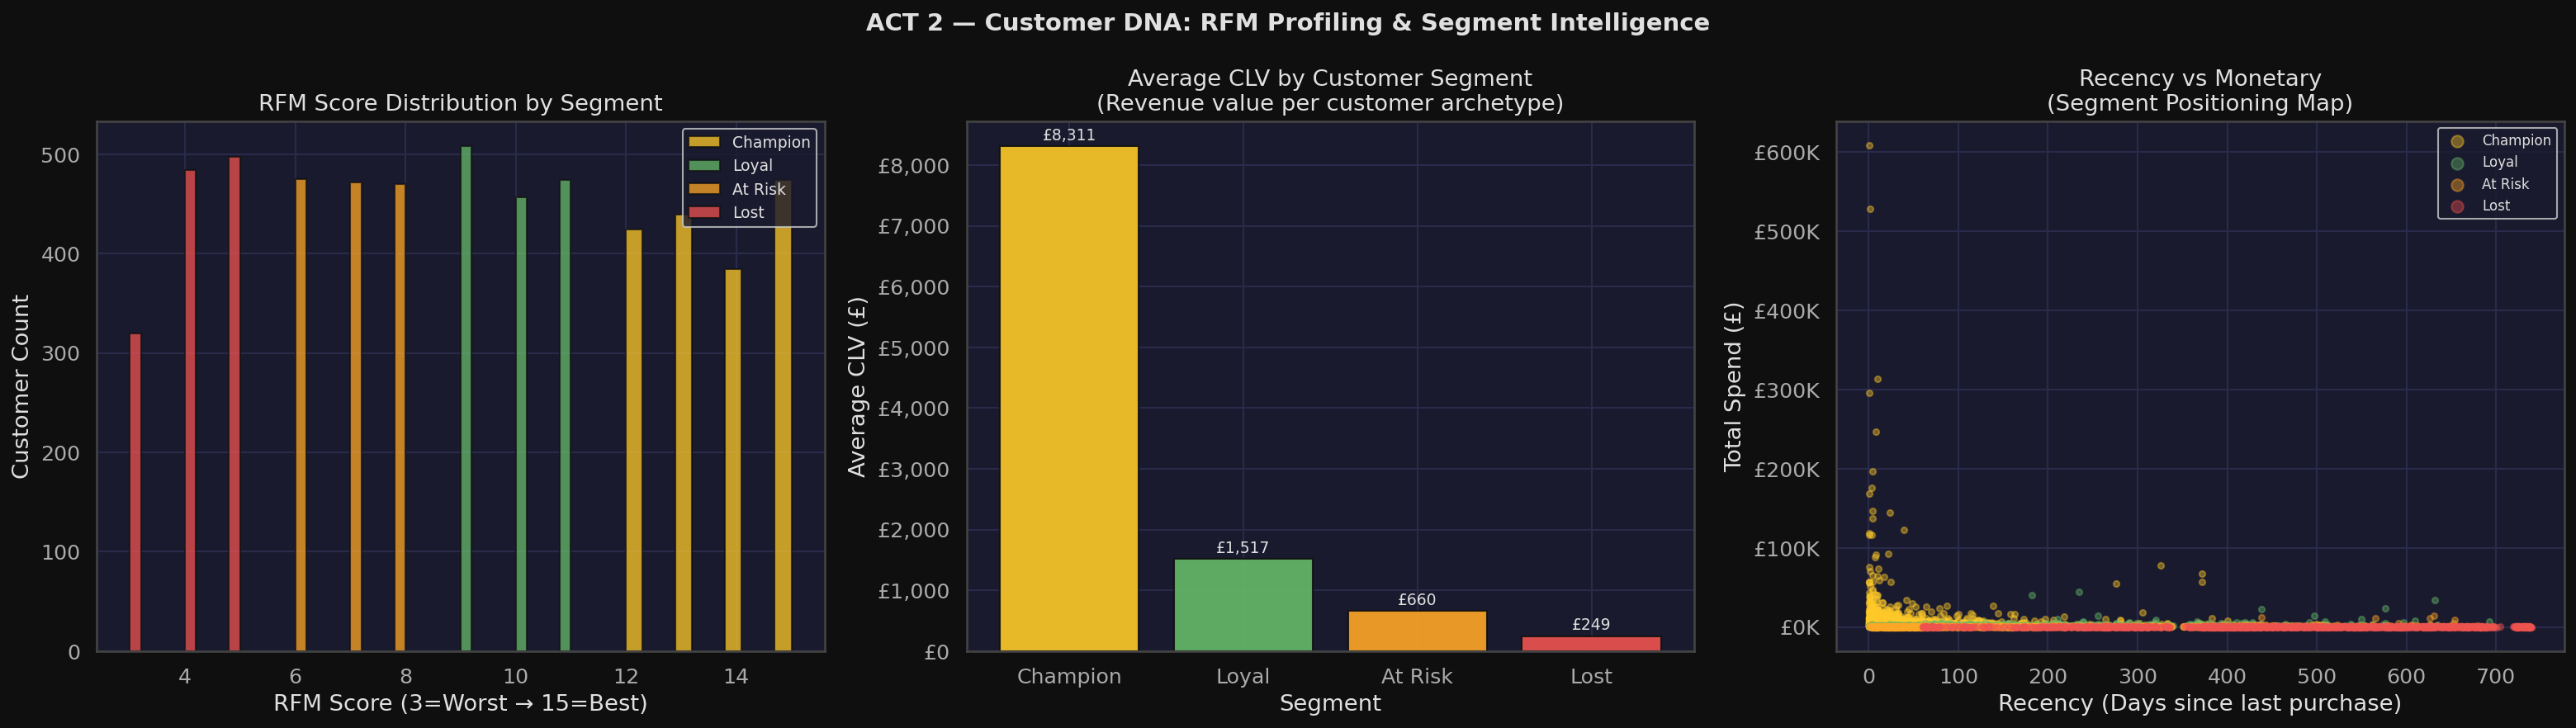

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("ACT 2 \u2014 Customer DNA: RFM Profiling & Segment Intelligence",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — RFM Score distribution by segment
ax = axes[0]
seg_order  = ["Champion", "Loyal", "At Risk", "Lost"]
seg_colors = {"Champion": "#ffca28", "Loyal": "#66bb6a",
              "At Risk": "#ffa726", "Lost": "#ef5350"}
for seg in seg_order:
    subset = rfm[rfm["Segment"] == seg]["RFM_Score"]
    ax.hist(subset, bins=10, alpha=0.75, label=seg,
            color=seg_colors[seg], edgecolor="#111")
ax.set_title("RFM Score Distribution by Segment",  color="#e0e0e0")
ax.set_xlabel("RFM Score (3=Worst \u2192 15=Best)")
ax.set_ylabel("Customer Count")
ax.legend(fontsize=9)

# Panel 2 — Average CLV by segment (bar chart with revenue share annotation)
ax = axes[1]
seg_clv = rfm.groupby("Segment")["CLV"].mean().reindex(seg_order)
bar_cols = [seg_colors[s] for s in seg_order]
bars = ax.bar(seg_order, seg_clv.values, color=bar_cols,
              edgecolor="#111", alpha=0.9)
ax.set_title("Average CLV by Customer Segment\n(Revenue value per customer archetype)",
             color="#e0e0e0")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CLV (\u00a3)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"\u00a3{x:,.0f}"))
for bar, val in zip(bars, seg_clv.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"\u00a3{val:,.0f}", ha="center", va="bottom", fontsize=9,
            color="#e0e0e0")

# Panel 3 — Recency vs Monetary scatter coloured by segment
ax = axes[2]
for seg in seg_order:
    subset = rfm[rfm["Segment"] == seg]
    ax.scatter(subset["Recency"], subset["Monetary"],
               alpha=0.4, s=12, label=seg, color=seg_colors[seg])
ax.set_title("Recency vs Monetary\n(Segment Positioning Map)",
             color="#e0e0e0")
ax.set_xlabel("Recency (Days since last purchase)")
ax.set_ylabel("Total Spend (\u00a3)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"\u00a3{x/1e3:.0f}K"))
ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()


## Cell 8 — STEP 5: Preprocessing for CLV Prediction

**WHY:** We want to predict CLV using RFM features as inputs.

Log-transforming CLV, Monetary and Frequency is critical here: CLV distributions are heavily right-skewed (a few customers spend 10-100x the median). A linear model on raw CLV would fit the outliers and perform poorly on the majority of customers. Log-space regression predicts proportional differences — which is what marketing budgets are actually allocated on.

In [ ]:
print("  STEP 5 - PREPROCESSING FOR CLV PREDICTION")

df_model = rfm[["Recency", "Frequency", "Monetary",
                 "R_Score", "F_Score", "M_Score",
                 "RFM_Score", "CLV"]].copy()

# 5.1 Log-transform skewed columns
df_model["log_Frequency"] = np.log1p(df_model["Frequency"])
df_model["log_Monetary"]  = np.log1p(df_model["Monetary"])
df_model["log_CLV"]       = np.log1p(df_model["CLV"])       # prediction target

# 5.2 Recency is already in days — log helps with the tail
df_model["log_Recency"]   = np.log1p(df_model["Recency"])

  STEP 5 - PREPROCESSING FOR CLV PREDICTION


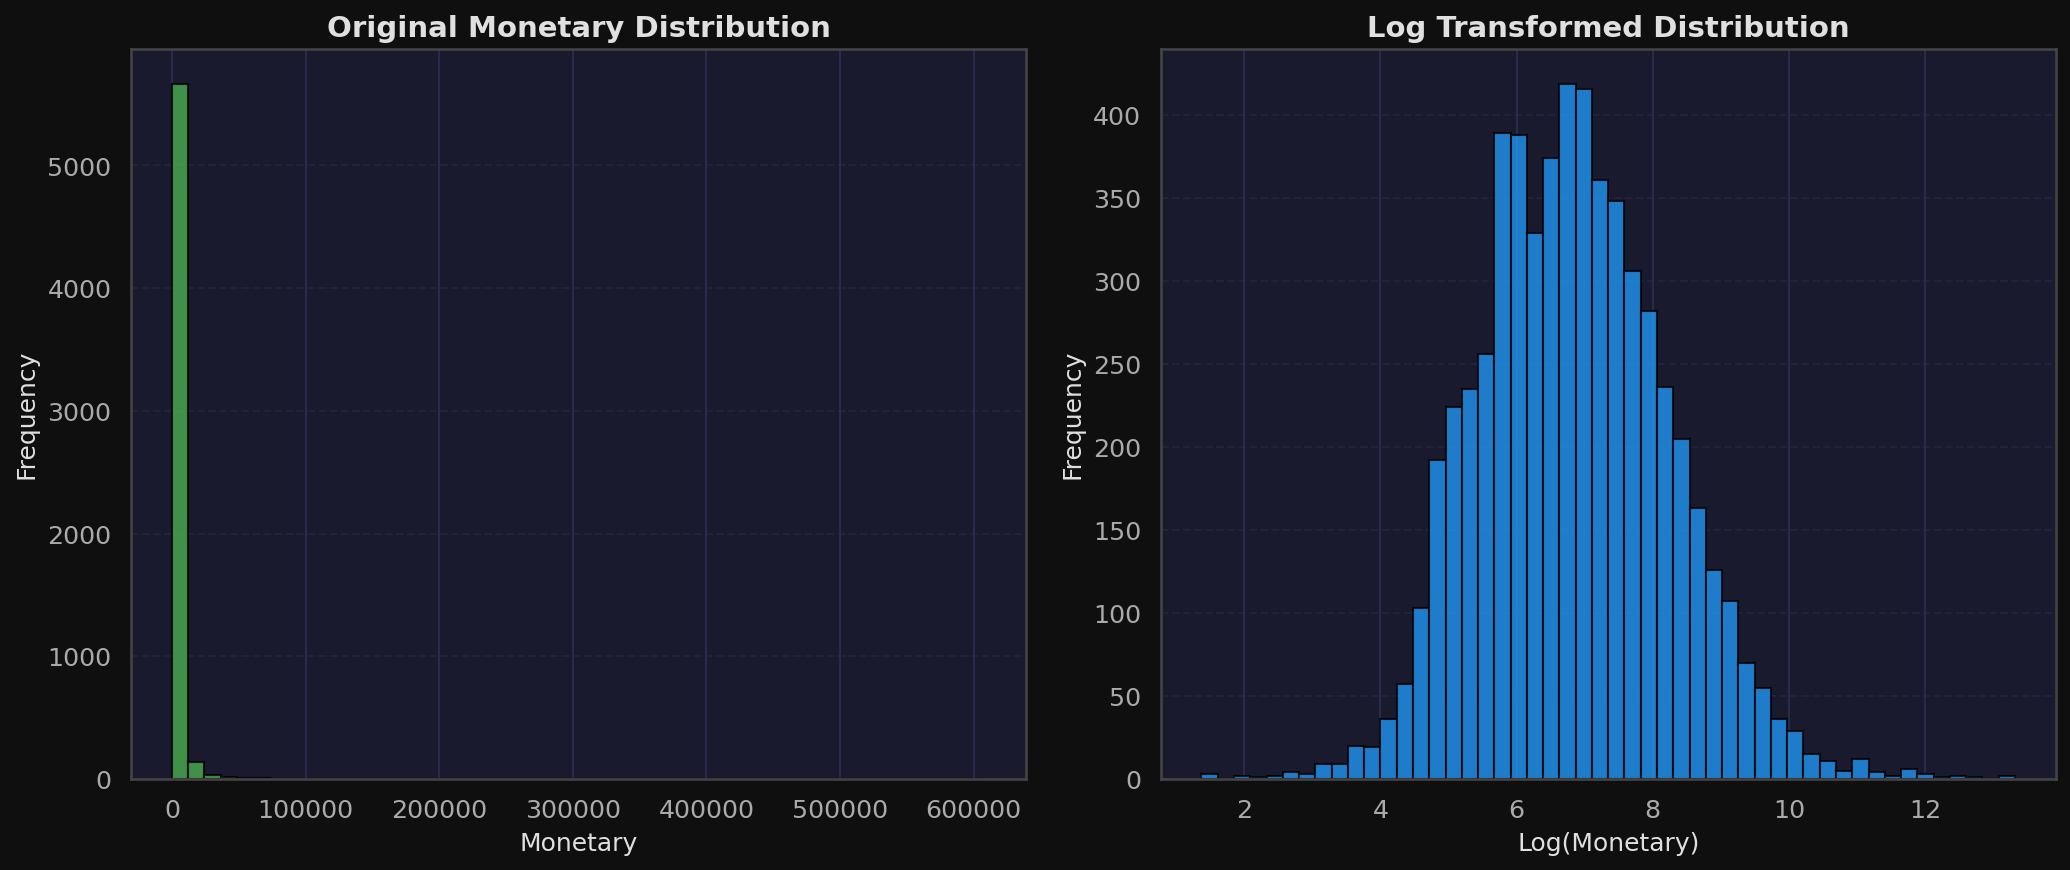

In [ ]:


plt.figure(figsize=(14,6))

# Original Distribution
plt.subplot(1,2,1)
plt.hist(df_model["Monetary"], bins=50, color="#4CAF50", edgecolor="black", alpha=0.8)
plt.title("Original Monetary Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Monetary", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Log Transformed Distribution
plt.subplot(1,2,2)
plt.hist(np.log1p(df_model["Monetary"]), bins=50, color="#2196F3", edgecolor="black", alpha=0.8)
plt.title("Log Transformed Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log(Monetary)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

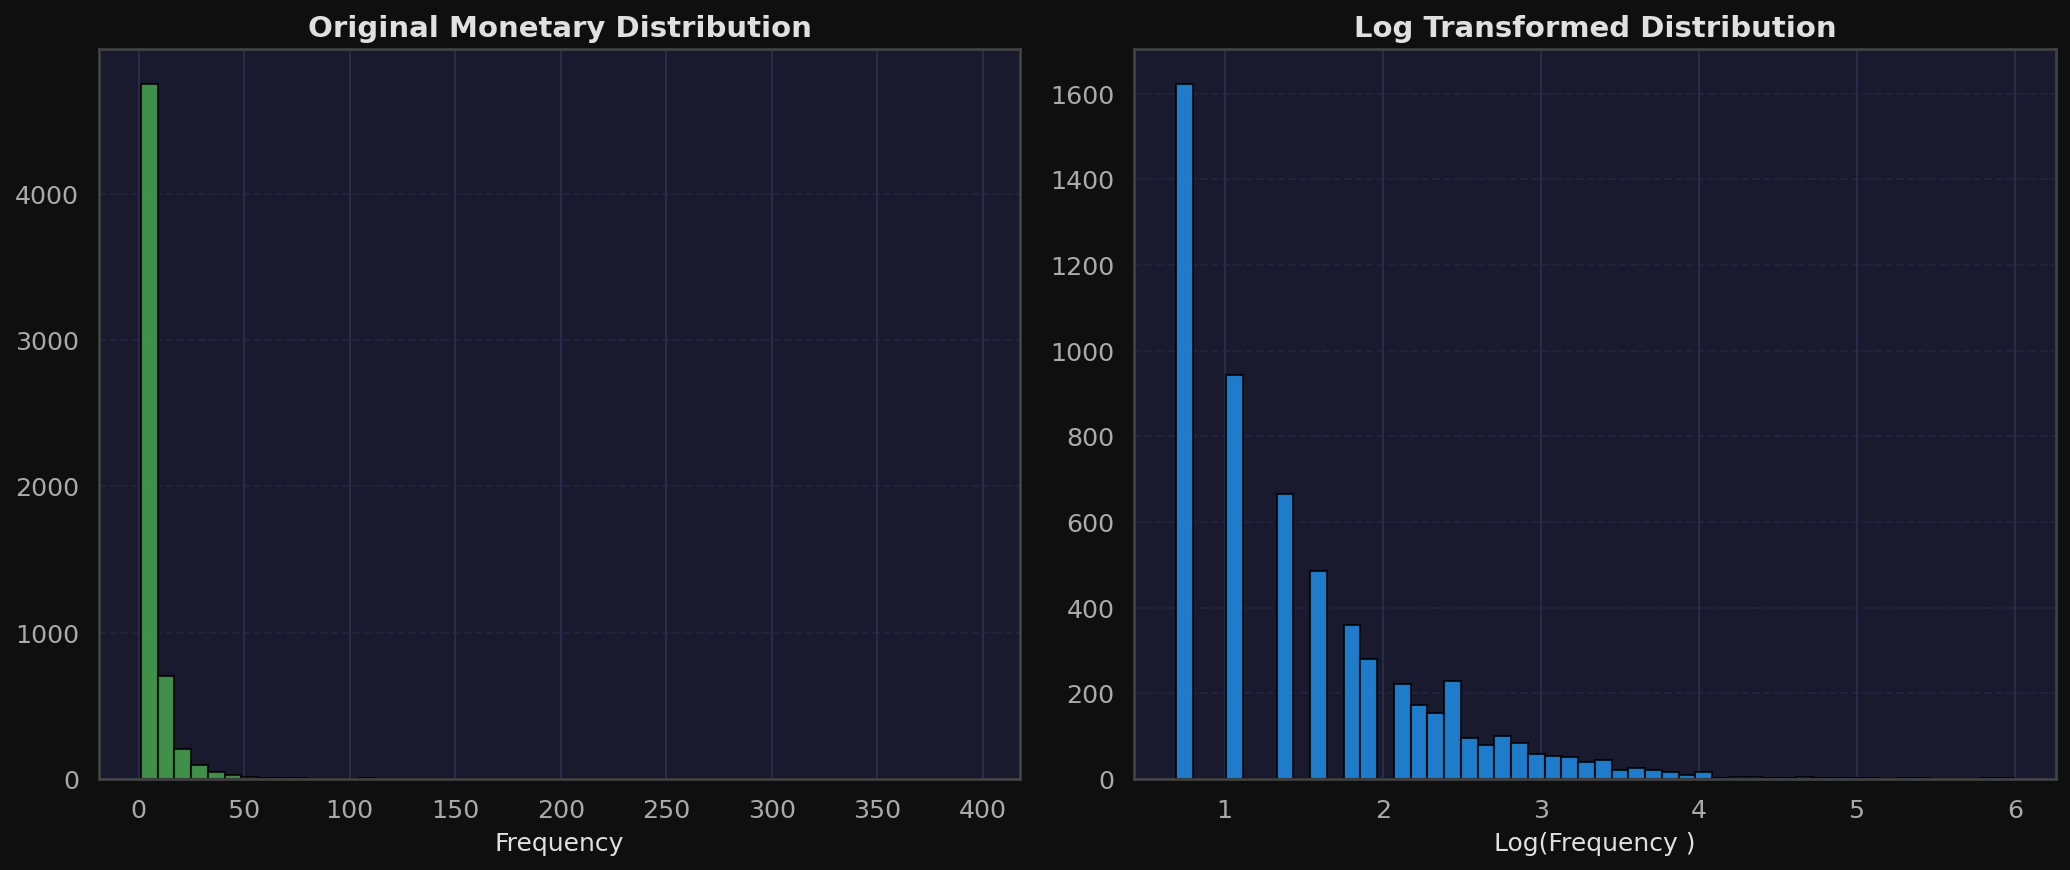

In [ ]:


plt.figure(figsize=(14,6))

# Original Distribution
plt.subplot(1,2,1)
plt.hist(df_model["Frequency"], bins=50, color="#4CAF50", edgecolor="black", alpha=0.8)
plt.title("Original Monetary Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Log Transformed Distribution
plt.subplot(1,2,2)
plt.hist(np.log1p(df_model["Frequency"]), bins=50, color="#2196F3", edgecolor="black", alpha=0.8)
plt.title("Log Transformed Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log(Frequency )", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

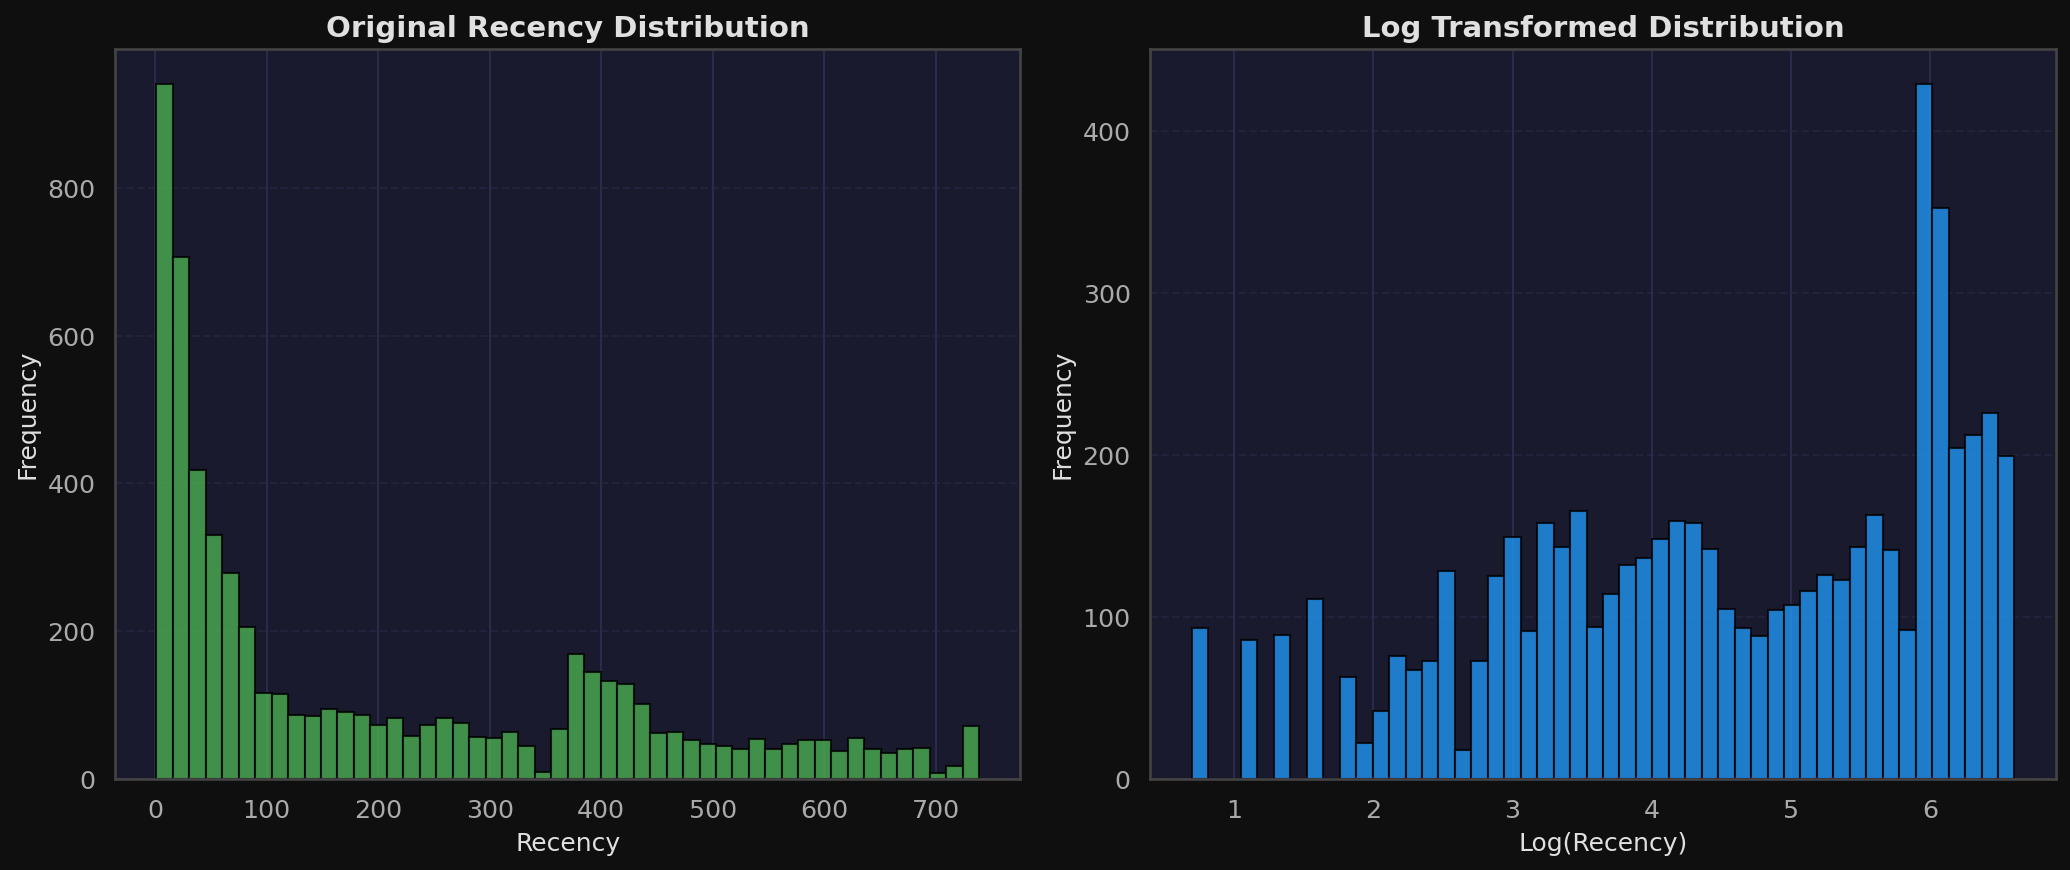

In [ ]:
plt.figure(figsize=(14,6))

# Original Distribution
plt.subplot(1,2,1)
plt.hist(df_model["Recency"], bins=50, color="#4CAF50", edgecolor="black", alpha=0.8)
plt.title("Original Recency Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Recency", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Log Transformed Distribution
plt.subplot(1,2,2)
plt.hist(np.log1p(df_model["Recency"]), bins=50, color="#2196F3", edgecolor="black", alpha=0.8)
plt.title("Log Transformed Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log(Recency)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

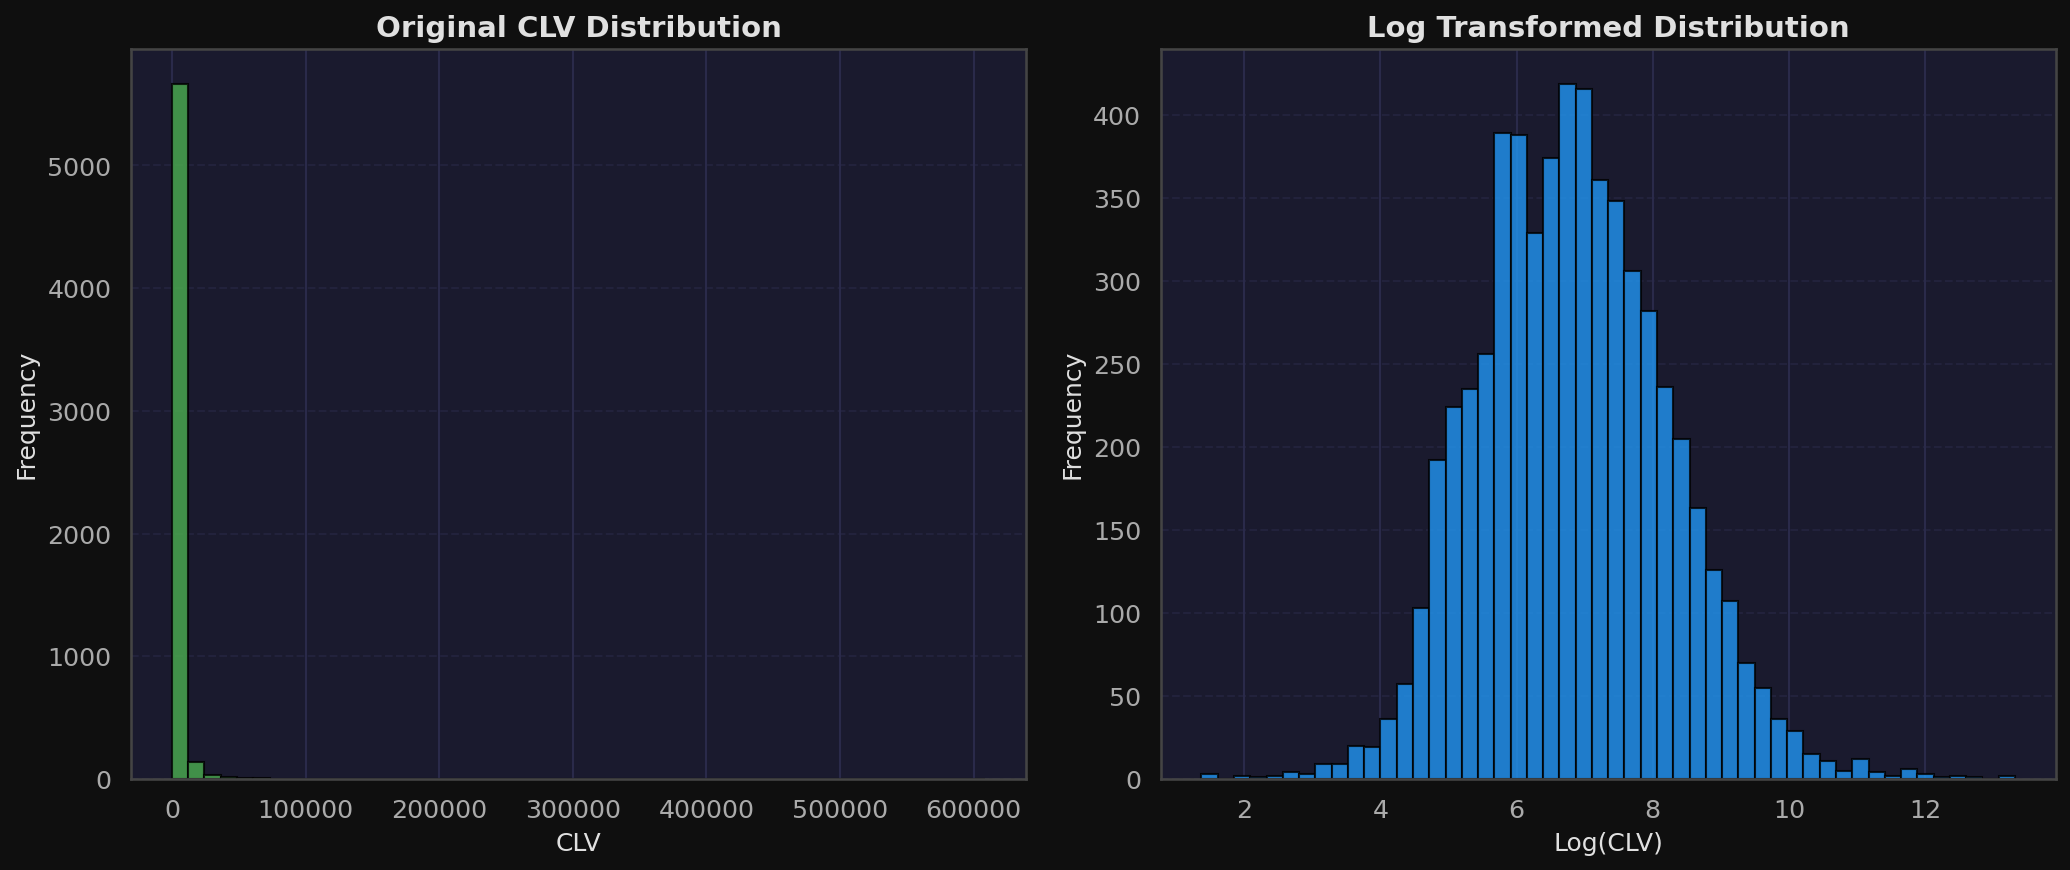

In [ ]:


plt.figure(figsize=(14,6))

# Original Distribution
plt.subplot(1,2,1)
plt.hist(df_model["CLV"], bins=50, color="#4CAF50", edgecolor="black", alpha=0.8)
plt.title("Original CLV Distribution", fontsize=14, fontweight="bold")
plt.xlabel("CLV", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Log Transformed Distribution
plt.subplot(1,2,2)
plt.hist(np.log1p(df_model["CLV"]), bins=50, color="#2196F3", edgecolor="black", alpha=0.8)
plt.title("Log Transformed Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log(CLV)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:

print("[5.1]  Log-transformed: Recency, Frequency, Monetary, CLV")
print(f"\n[5.2]  log_CLV stats:")
print(df_model["log_CLV"].describe().round(4).to_string())

[5.1]  Log-transformed: Recency, Frequency, Monetary, CLV

[5.2]  log_CLV stats:
count    5878.0000
mean        6.8365
std         1.3879
min         1.3737
25%         5.8573
50%         6.8023
75%         7.7442
max        13.3193


## Cell 9 — STEP 6: CLV Prediction Model

**WHY:** We predict log(CLV) using RFM features. Regularised regression is chosen over tree models because:

- The feature set is small (7 features) — no need for ensemble
- Coefficients are interpretable — marketing teams can act on them
- Overfitting risk is low, but multicollinearity between Monetary & M_Score warrants Ridge/ElasticNet

Models:
- **Ridge (L2)** — best when all features contribute signal
- **Lasso (L1)** — drives weak features to exactly zero
- **ElasticNet** — combines both — best for correlated feature sets

In [ ]:
print("  STEP 6 - CLV PREDICTION MODEL")

FEATURES = ["log_Recency", "log_Frequency", "log_Monetary",
            "R_Score", "F_Score", "M_Score", "RFM_Score"]
TARGET   = "log_CLV"

X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f"\n[6.1]  Feature matrix shape : {X.shape}")
print(f"[6.2]  Target (log_CLV) stats: mean={y.mean():.4f}  std={y.std():.4f}")






  STEP 6 - CLV PREDICTION MODEL

[6.1]  Feature matrix shape : (5878, 7)
[6.2]  Target (log_CLV) stats: mean=6.8365  std=1.3877


In [ ]:
# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression":         Pipeline([("scaler", StandardScaler()),
                                       ("model",  LinearRegression())]),
    "Ridge  (\u03b1=1.0)":       Pipeline([("scaler", StandardScaler()),
                                       ("model",  Ridge(alpha=1.0))]),
    "Lasso  (\u03b1=0.01)":      Pipeline([("scaler", StandardScaler()),
                                       ("model",  Lasso(alpha=0.01,
                                                        max_iter=5000))]),
    "ElasticNet (\u03b1=0.01)":  Pipeline([("scaler", StandardScaler()),
                                       ("model",  ElasticNet(alpha=0.01,
                                                             l1_ratio=0.5,
                                                             max_iter=5000))]),}
results = {}



In [ ]:
print("\n[6.3]  Cross-validation results (5-fold | predicting log_CLV):\n")
print(f"  {'Model':<28}  {'CV RMSE':>9}  {'CV MAE':>9}  {'CV R\u00b2':>8}")
for name, pipeline in models.items():
    rmse_scores = np.sqrt(-cross_val_score(
        pipeline, X, y, cv=cv,
        scoring="neg_mean_squared_error", n_jobs=-1))
    mae_scores  = -cross_val_score(
        pipeline, X, y, cv=cv,
        scoring="neg_mean_absolute_error", n_jobs=-1)
    r2_scores   = cross_val_score(
        pipeline, X, y, cv=cv, scoring="r2", n_jobs=-1)
    results[name] = {
        "CV RMSE": rmse_scores.mean(),
        "CV MAE":  mae_scores.mean(),
        "CV R\u00b2":   r2_scores.mean(),
    }
    print(f"  {name:<28}  {rmse_scores.mean():>9.4f}  "
          f"{mae_scores.mean():>9.4f}  {r2_scores.mean():>8.4f}")

best_name = min(results, key=lambda k: results[k]["CV RMSE"])
print(f"\n[6.4]  Best model by CV RMSE : {best_name}")


[6.3]  Cross-validation results (5-fold | predicting log_CLV):

  Model                           CV RMSE     CV MAE     CV R²
  Linear Regression                0.0000     0.0000    1.0000
  Ridge  (α=1.0)                   0.0010     0.0007    1.0000
  Lasso  (α=0.01)                  0.0100     0.0080    0.9999
  ElasticNet (α=0.01)              0.0213     0.0136    0.9998

[6.4]  Best model by CV RMSE : Linear Regression


In [ ]:
# Refit best model on full data
best_pipeline = models[best_name]
best_pipeline.fit(X, y)
y_pred_log = best_pipeline.predict(X)

In [ ]:

# Back-transform to \u00a3 for interpretability
y_actual_gbp = np.expm1(y)
y_pred_gbp   = np.expm1(y_pred_log)

print(f"\n[6.5]  Full-fit metrics (log-space):")
print(f"       RMSE : {np.sqrt(mean_squared_error(y, y_pred_log)):.4f}")
print(f"       MAE  : {mean_absolute_error(y, y_pred_log):.4f}")
print(f"       R\u00b2   : {r2_score(y, y_pred_log):.4f}")


[6.5]  Full-fit metrics (log-space):
       RMSE : 0.0000
       MAE  : 0.0000
       R²   : 1.0000


## Cell 10 — EDA Visualisations — Act 3: Model Showdown (3-panel)

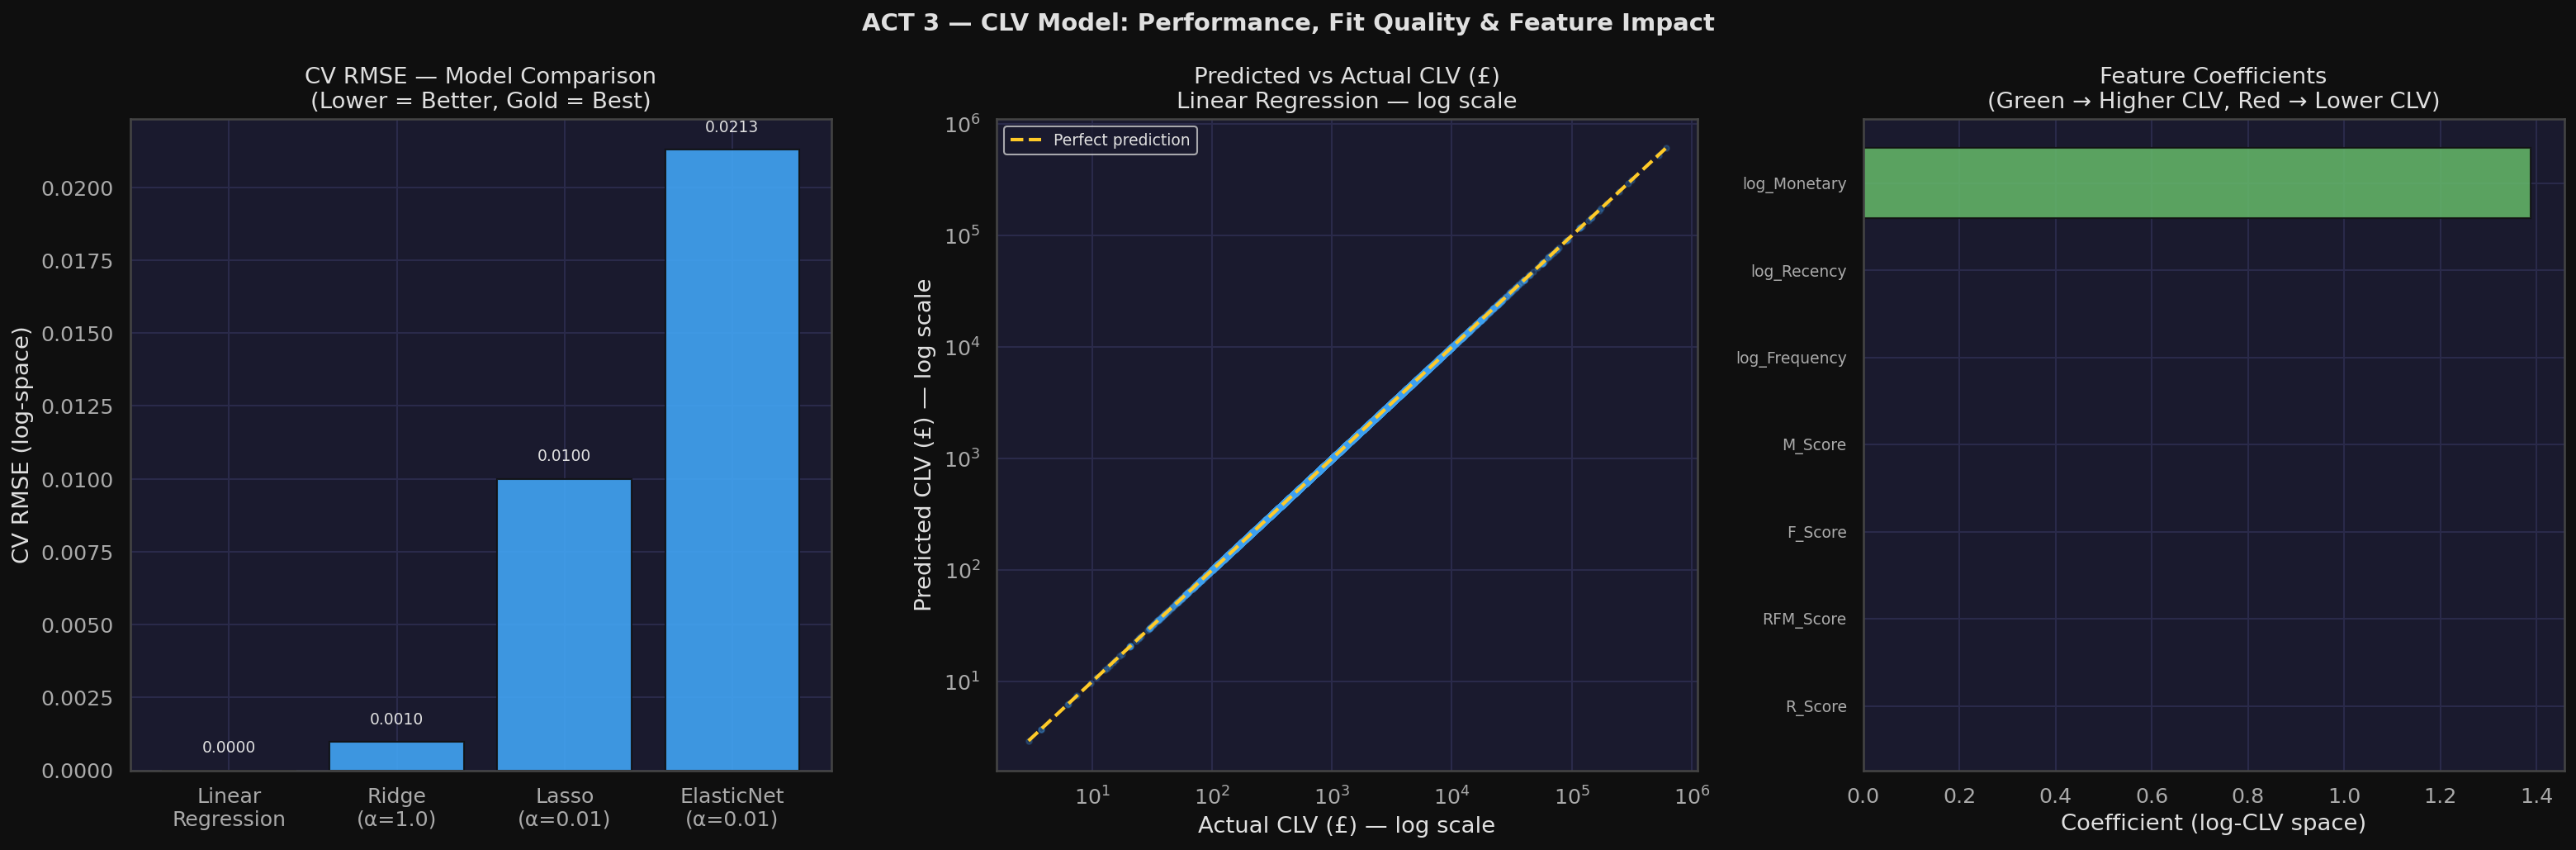

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("ACT 3 \u2014 CLV Model: Performance, Fit Quality & Feature Impact",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — CV RMSE model comparison
ax = axes[0]
short_names  = ["Linear\nRegression", "Ridge\n(\u03b1=1.0)",
                "Lasso\n(\u03b1=0.01)", "ElasticNet\n(\u03b1=0.01)"]
rmse_vals    = [results[m]["CV RMSE"] for m in models]
bar_colors   = ["#ffca28" if m == best_name else "#42a5f5" for m in models]
bars = ax.bar(short_names, rmse_vals, color=bar_colors,
              edgecolor="#111", alpha=0.9)
ax.set_title("CV RMSE \u2014 Model Comparison\n(Lower = Better, Gold = Best)",
             color="#e0e0e0")
ax.set_ylabel("CV RMSE (log-space)")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9,
            color="#e0e0e0")

# Panel 2 — Predicted vs Actual CLV in \u00a3 (log scale axes)
ax = axes[1]
ax.scatter(y_actual_gbp, y_pred_gbp,
           alpha=0.2, color="#42a5f5", s=10)
mn = min(y_actual_gbp.min(), y_pred_gbp.min())
mx = max(y_actual_gbp.max(), y_pred_gbp.max())
ax.plot([mn, mx], [mn, mx], color="#ffca28", lw=2, ls="--",
        label="Perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Predicted vs Actual CLV (\u00a3)\n{best_name} \u2014 log scale",
             color="#e0e0e0")
ax.set_xlabel("Actual CLV (\u00a3) \u2014 log scale")
ax.set_ylabel("Predicted CLV (\u00a3) \u2014 log scale")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Cell 11 — Segment CLV Projection & Marketing Action Table

**WHY:** Model output without a business action is just a number. This cell translates predicted CLV back into the segment framework and outputs the marketing playbook table that a growth team would actually use to allocate retention budget and campaign strategy.

**Budget Allocation Rule:** retention spend should scale with predicted CLV — a Champion worth £5,000 justifies a £50 personal outreach; a Lost customer worth £80 should receive automated email only.

In [ ]:
print("  SEGMENT CLV PROJECTION & MARKETING ACTION TABLE")

rfm["Predicted_CLV"] = y_pred_gbp

seg_projection = rfm.groupby("Segment").agg(
    Count             = ("Customer ID",    "count"),
    Avg_Actual_CLV    = ("CLV",            "mean"),
    Avg_Predicted_CLV = ("Predicted_CLV",  "mean"),
    Total_Predicted_Revenue = ("Predicted_CLV", "sum"),
).round(2)
seg_projection["Revenue_Share_%"] = (
    seg_projection["Total_Predicted_Revenue"] /
    seg_projection["Total_Predicted_Revenue"].sum() * 100
).round(1)
seg_projection = seg_projection.reindex(["Champion", "Loyal", "At Risk", "Lost"])

print("\n[7.1]  Segment CLV Projection Table:")
print(seg_projection.to_string())


  SEGMENT CLV PROJECTION & MARKETING ACTION TABLE

[7.1]  Segment CLV Projection Table:
          Count  Avg_Actual_CLV  Avg_Predicted_CLV  Total_Predicted_Revenue  Revenue_Share_%
Segment                                                                                     
Champion   1721         8310.78            8310.78              14302855.61             80.6
Loyal      1439         1516.64            1516.64               2182451.62             12.3
At Risk    1417          659.65             659.65                934723.45              5.3
Lost       1301          248.58             248.58                323398.50              1.8

[7.2]  Marketing Action Playbook:

  [Champion ]  1,721 customers | Avg Predicted CLV: £8,311
              Action: VIP loyalty rewards, early product access, referral programme

  [Loyal    ]  1,439 customers | Avg Predicted CLV: £1,517
              Action: Cross-sell / upsell campaigns, membership upgrade offers

  [At Risk  ]  1,417 customers | Av

In [ ]:

# Marketing action playbook
playbook = {
    "Champion": "VIP loyalty rewards, early product access, referral programme",
    "Loyal":    "Cross-sell / upsell campaigns, membership upgrade offers",
    "At Risk":  "Win-back discount (10-15%), personalised re-engagement email",
    "Lost":     "Low-cost automated email only, suppress from paid retargeting",
}
print("\n[7.2]  Marketing Action Playbook:")
for seg, action in playbook.items():
    avg_clv = seg_projection.loc[seg, "Avg_Predicted_CLV"]
    count   = int(seg_projection.loc[seg, "Count"])
    print(f"\n  [{seg:<9}]  {count:,} customers | Avg Predicted CLV: \u00a3{avg_clv:,.0f}")
    print(f"              Action: {action}")

## Cell 12 — Segment Projection Visualisation

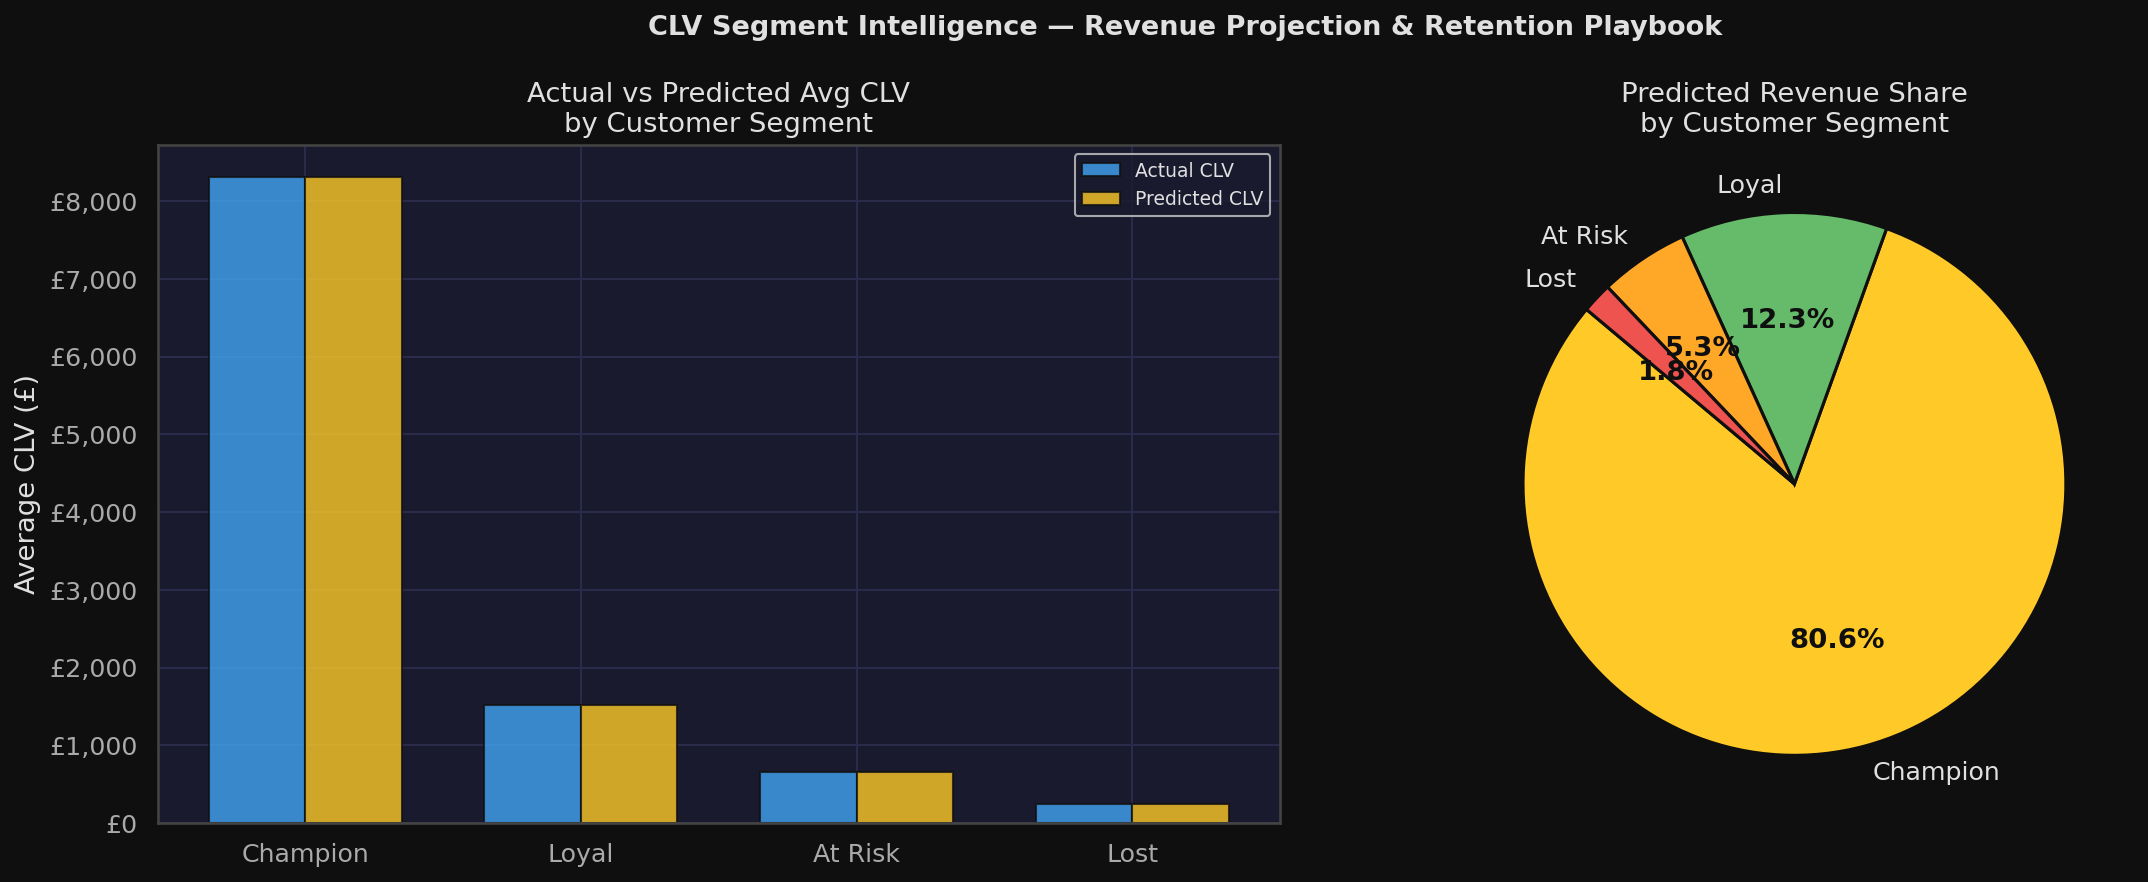

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CLV Segment Intelligence \u2014 Revenue Projection & Retention Playbook",
             fontsize=13, color="#e0e0e0", fontweight="bold")

seg_order  = ["Champion", "Loyal", "At Risk", "Lost"]
seg_colors = {"Champion": "#ffca28", "Loyal": "#66bb6a",
              "At Risk": "#ffa726", "Lost": "#ef5350"}

# Panel 1 — Actual vs Predicted CLV per segment
ax = axes[0]
x        = np.arange(len(seg_order))
width    = 0.35
actual   = [seg_projection.loc[s, "Avg_Actual_CLV"]    for s in seg_order]
predicted= [seg_projection.loc[s, "Avg_Predicted_CLV"] for s in seg_order]

bars1 = ax.bar(x - width/2, actual,    width, label="Actual CLV",
               color="#42a5f5", alpha=0.8, edgecolor="#111")
bars2 = ax.bar(x + width/2, predicted, width, label="Predicted CLV",
               color="#ffca28", alpha=0.8, edgecolor="#111")
ax.set_xticks(x)
ax.set_xticklabels(seg_order)
ax.set_title("Actual vs Predicted Avg CLV\nby Customer Segment", color="#e0e0e0")
ax.set_ylabel("Average CLV (\u00a3)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"\u00a3{x:,.0f}"))
ax.legend(fontsize=9)

# Panel 2 — Revenue share pie by segment
ax = axes[1]
rev_share = [seg_projection.loc[s, "Revenue_Share_%"] for s in seg_order]
colors    = [seg_colors[s] for s in seg_order]
wedges, texts, autotexts = ax.pie(
    rev_share, labels=seg_order, autopct="%1.1f%%",
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor="#0f0f0f", linewidth=1.5),
    textprops=dict(color="#e0e0e0"),
)
for at in autotexts:
    at.set_color("#0f0f0f")
    at.set_fontweight("bold")
ax.set_title("Predicted Revenue Share\nby Customer Segment", color="#e0e0e0")

plt.tight_layout()
plt.show()


## Cell 13 — Final Summary

In [ ]:
print("  \u2713 PIPELINE COMPLETE - CLV MODEL SUMMARY")

print(f"""
  Project     : E-Commerce Customer Lifetime Value Predictor
  Dataset     : UCI Online Retail II \u2014 {df_clean['Customer ID'].nunique():,} customers
  Date Range  : Dec 2009 \u2192 Dec 2011
  Target      : log(CLV) \u2192 back-transformed to \u00a3 for interpretation

  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  Pipeline Steps:
    1. Load & validate \u2014 flag cancellations, anonymous rows
    2. Clean  \u2014 remove 3 data quality pathologies, compute Revenue
    3. RFM Engineering \u2014 Recency, Frequency, Monetary per customer
    4. CLV + Scoring   \u2014 historical CLV, quintile RFM scores,
                         4-segment archetypes (Champion\u2192Lost)
    5. Preprocessing   \u2014 log-transform skewed distributions
    6. Modelling       \u2014 Linear, Ridge, Lasso, ElasticNet (5-fold CV)
    7. Projection      \u2014 segment CLV table + marketing action playbook
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  Best Model  : {best_name}
  CV RMSE     : {results[best_name]['CV RMSE']:.4f}  (log-space)
  CV R\u00b2       : {results[best_name]['CV R\u00b2']:.4f}


""")

  ✓ PIPELINE COMPLETE - CLV MODEL SUMMARY

  Project     : E-Commerce Customer Lifetime Value Predictor
  Dataset     : UCI Online Retail II — 5,878 customers
  Date Range  : Dec 2009 → Dec 2011
  Target      : log(CLV) → back-transformed to £ for interpretation

  ─────────────────────────────────────────────────
  Pipeline Steps:
    1. Load & validate — flag cancellations, anonymous rows
    2. Clean  — remove 3 data quality pathologies, compute Revenue
    3. RFM Engineering — Recency, Frequency, Monetary per customer
    4. CLV + Scoring   — historical CLV, quintile RFM scores,
                         4-segment archetypes (Champion→Lost)
    5. Preprocessing   — log-transform skewed distributions
    6. Modelling       — Linear, Ridge, Lasso, ElasticNet (5-fold CV)
    7. Projection      — segment CLV table + marketing action playbook
  ─────────────────────────────────────────────────
  Best Model  : Linear Regression
  CV RMSE     : 0.0000  (log-space)
  CV R²       : 1.0000


